In [409]:
import numpy as np
import pandas as pd

In [410]:
df = pd.read_csv(r'data/Laptop_Train_v2.csv')
df = df[df["polarity"] != "conflict"]
df.columns

Index(['id', 'Sentence', 'Aspect Term', 'polarity', 'from', 'to'], dtype='object')

In [411]:
print(df.columns)
print(df.shape)
print(df['polarity'].value_counts())

Index(['id', 'Sentence', 'Aspect Term', 'polarity', 'from', 'to'], dtype='object')
(2313, 6)
polarity
positive    987
negative    866
neutral     460
Name: count, dtype: int64


In [412]:
df['text'] =(df['Sentence'].astype(str) + ' [SEP] ' +
             df['Aspect Term'].astype(str))

In [413]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df['polarity'])

print(le.classes_)

['negative' 'neutral' 'positive']


In [414]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(df['text'],y,test_size=0.2,random_state=42,stratify=y)

In [415]:
X_train.iloc[5]

"I've been impressed with the battery life and the performance for such a small amount of memory. [SEP] battery life"

In [416]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 10000

tokenizer = Tokenizer(
    num_words = MAX_WORDS,
    oov_token = '<OOV>'
)

tokenizer.fit_on_texts(X_train)

In [417]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

for i in range(10):
    print(X_train_seq[i])

lengths = [len(x) for x in X_train_seq]
print("Max Length: ",max(lengths))
print("Avg Length: ",np.percentile(lengths,99))

[4, 2, 24, 19, 16, 121, 9, 603, 435, 11, 293, 63, 653, 4, 521, 4, 159, 3, 159]
[1318, 274, 728, 32, 146, 275, 55, 251, 340, 4, 137, 552, 2157, 5, 2158, 8, 3, 340]
[265, 490, 130, 13, 9, 2159, 9, 2, 2160, 815, 3, 490, 130]
[30, 7, 816, 47, 25, 2161, 6, 2162, 2, 1083, 10, 7, 53, 392, 16, 436, 3, 25]
[30, 12, 106, 31, 22, 283, 12, 35, 654, 8, 182, 12, 7, 207, 10, 128, 6, 1319, 1084, 87, 3, 35, 654]
[252, 151, 729, 12, 2, 21, 41, 4, 2, 89, 11, 163, 7, 321, 1085, 10, 85, 3, 21, 41]
[2, 24, 9, 266, 4, 2, 1086, 182, 27, 459, 2, 29, 4, 2, 922, 52, 817, 143, 3, 24]
[2, 1087, 138, 393, 13, 59, 6, 2163, 19, 218, 2, 604, 1629, 32, 60, 110, 8, 11, 44, 28, 6, 23, 5, 1630, 2, 655, 64, 2, 183, 3, 604]
[226, 1320, 5, 2, 415, 37, 81, 341, 102, 460, 38, 242, 3, 242]
[36, 11, 163, 7, 38, 43, 3, 43]
Max Length:  79
Avg Length:  61.0


In [418]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 61
X_train_pad = pad_sequences(X_train_seq,maxlen=MAX_LEN,padding='post',truncating='post')
X_test_pad = pad_sequences(X_test_seq,maxlen=MAX_LEN,padding='post',truncating='post')


In [419]:
vocab_size = len(tokenizer.word_index) + 1

print(vocab_size)

2935


In [420]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Embedding(
        input_dim=2953,
        output_dim=100,
        input_length=61
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\w10\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_25 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_25                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [421]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=32,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/32
58/58 ━━━━━━━━━━━━━━━━━━━━ 34s 103ms/step - accuracy: 0.4568 - loss: 1.0826 - val_accuracy: 0.5119 - val_loss: 0.9859
Epoch 2/32
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.6492 - loss: 0.8062 - val_accuracy: 0.6782 - val_loss: 0.7673
Epoch 3/32
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.7941 - loss: 0.5270 - val_accuracy: 0.7063 - val_loss: 0.7446
Epoch 4/32
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.8470 - loss: 0.3937 - val_accuracy: 0.7063 - val_loss: 0.7744
Epoch 5/32
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.8865 - loss: 0.3016 - val_accuracy: 0.6976 - val_loss: 0.8748
Epoch 6/32
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9081 - loss: 0.2541 - val_accuracy: 0.6890 - val_loss: 0.9496
Epoch 7/32
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.9114 - loss: 0.2353 - val_accuracy: 0.7149 - val_loss: 0.9509
Epoch 8/32
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.9108 - loss: 0.2091 - val_accuracy: 0.7257

In [422]:
loss, acc = model.evaluate(X_test_pad, y_test)
print(acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7257 - loss: 0.9363
0.7257019281387329


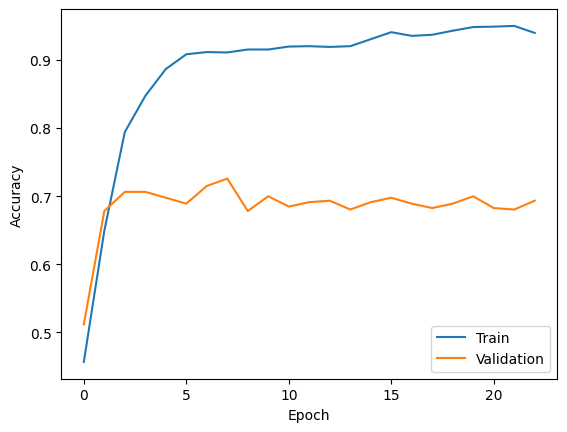

In [423]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [424]:
y_pred = model.predict(X_test_pad)
from sklearn.metrics import confusion_matrix,accuracy_score

y_pred = np.argmax(y_pred, axis=1)

print(confusion_matrix(y_test,y_pred))
ac = accuracy_score(y_test,y_pred)
print(ac)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
[[137  21  15]
 [ 23  55  14]
 [ 31  23 144]]
0.7257019438444925


In [426]:
import joblib

# Save tokenizer
joblib.dump(tokenizer, r"models/tokenizer.pkl")

# Save label encoder
joblib.dump(le, r"models/label_encoder.pkl")

# Save model
model.save(r"models/absa_bilstm_attention.keras")